<a href="https://colab.research.google.com/github/mjgpinheiro/Econophysics/blob/main/Money_Tensor_crisis_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Money as a Tensor: Nonlinear Dynamics and Financial Contagion

**Pinheiro & Pinheiro (2025)**

This notebook implements the toy model accompanying the paper:
*"Money as a Tensor: Nonlinear Dynamics, Stability Analysis,
and the Propagation of Financial Shocks in Multidimensional Economies"*

---

## Model Summary

We represent monetary flows as a matrix $M(t) \in \mathbb{R}^{N_S \times N_A}$,
where entry $M_{ij}(t)$ encodes capital flowing from sector $i$ to agent class $j$.

The deviation from equilibrium $x_{ij}(t) = M_{ij}(t) - M^*_{ij}$
obeys the **tensorial Langevin equation**:

$$\dot{x}_{ij} = \sum_{kl} \mathcal{K}_{ijkl}\, x_{kl} - \Gamma_{ij}\, x_{ij} + s_{ij}(t)$$

In vectorised form: $\dot{\mathbf{x}} = A\,\mathbf{x} + \mathbf{s}(t)$,
where $A = \mathcal{K}_{\text{flat}} - \text{diag}(\boldsymbol{\Gamma})$.

**Stability** is guaranteed when $\alpha(A) < 0$ (spectral abscissa),
via the Lyapunov function $\mathcal{V}(\mathbf{x}) = \mathbf{x}^\top P\,\mathbf{x}$
where $P$ solves $A^\top P + PA = -I$.

## 0. Imports and reproducibility

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.linalg import solve_continuous_lyapunov
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm
import warnings
warnings.filterwarnings('ignore')

# Reproducible random seed
rng = np.random.default_rng(42)

print("Libraries loaded. NumPy:", np.__version__)

Libraries loaded. NumPy: 2.0.2


## 1. Economy definition

We consider a **3-sector × 3-agent** economy:

| Index | Sector | | Index | Agent |
|---|---|---|---|---|
| 0 | Manufacturing | | 0 | Households |
| 1 | Finance | | 1 | Firms |
| 2 | Services | | 2 | Government |

In [2]:
SECTORS = ['Manufacturing', 'Finance', 'Services']
AGENTS  = ['Households',   'Firms',   'Government']
NS, NA  = 3, 3

### 1.1 Equilibrium capital flows $M^*$

$M^*_{ij}$ is the steady-state capital flow from sector $i$ to agent $j$
(normalised units; calibrated to reproduce stylised pre-2008 flow ratios).

In [3]:
M_STAR = np.array([
    [3.00, 2.50, 1.50],   # Manufacturing → {HH, Firms, Govt}
    [1.50, 4.00, 1.00],   # Finance       → {HH, Firms, Govt}
    [3.50, 2.00, 2.00],   # Services      → {HH, Firms, Govt}
])

print("Equilibrium M*:")
print(M_STAR)
print(f"\nTotal equilibrium capital stock: {M_STAR.sum():.2f}")

Equilibrium M*:
[[3.  2.5 1.5]
 [1.5 4.  1. ]
 [3.5 2.  2. ]]

Total equilibrium capital stock: 21.00


### 1.2 Friction tensor $\Gamma$

$\Gamma_{ij} > 0$ is the mean-reversion rate of flow $(i,j)$.
Its inverse $\tau_{ij} = \Gamma_{ij}^{-1}$ is the characteristic recovery time
(in quarters) in the absence of cross-sector coupling.

In [4]:
GAMMA = np.array([
    [0.10, 0.12, 0.06],   # Manufacturing
    [0.15, 0.18, 0.08],   # Finance
    [0.08, 0.11, 0.05],   # Services
])

print("Friction rates Γ_ij:")
print(GAMMA)
print("\nCharacteristic recovery times τ_ij = 1/Γ_ij (quarters):")
print(np.round(1/GAMMA, 1))

Friction rates Γ_ij:
[[0.1  0.12 0.06]
 [0.15 0.18 0.08]
 [0.08 0.11 0.05]]

Characteristic recovery times τ_ij = 1/Γ_ij (quarters):
[[10.   8.3 16.7]
 [ 6.7  5.6 12.5]
 [12.5  9.1 20. ]]


### 1.3 Coupling tensor $\mathcal{K}$

$\mathcal{K}_{ijkl}$ encodes how a deviation in sector-$k$/agent-$l$ flow
propagates to sector-$i$/agent-$j$.

- **Negative entries**: contagion / crowding out
- **Positive entries**: complementarity / stabilisation

The non-zero entries below represent:
- **Credit crunch channel**: Finance/Firms collapse → Manufacturing/Firms, Services/Firms
- **Demand channel**: Finance/Firms → Manufacturing/Households
- **Supply-chain spillover**: Manufacturing/Firms → Services/Firms (positive)
- **Automatic stabilisers**: Government → Manufacturing and Services (positive)
- **Feedback**: Manufacturing contraction feeds back into Finance

In [5]:
K = np.zeros((NS, NA, NS, NA))

# Finance-Firms shock propagation
K[0, 1, 1, 1] = -0.08   # F/Fi → M/Fi  (credit crunch)
K[0, 0, 1, 1] = -0.05   # F/Fi → M/HH  (consumer demand)
K[0, 0, 1, 0] = -0.04   # F/HH → M/HH
K[0, 2, 1, 2] = -0.02   # F/Fi → M/G

K[2, 1, 1, 1] = -0.07   # F/Fi → S/Fi
K[2, 0, 1, 0] = -0.04   # F/HH → S/HH

# Supply chain (positive spillover)
K[2, 1, 0, 1] = +0.03   # M/Fi → S/Fi
K[2, 0, 0, 0] = +0.02   # M/HH → S/HH

# Automatic fiscal stabilisers
K[0, 2, 2, 2] = +0.02   # G/G → M/G
K[2, 2, 2, 2] = +0.02   # G/G → S/G

# Feedback from Manufacturing to Finance
K[1, 0, 0, 0] = -0.02   # M/HH → F/HH

print("Non-zero coupling entries K[i,j,k,l]:")
for i in range(NS):
    for j in range(NA):
        for k in range(NS):
            for l in range(NA):
                if K[i,j,k,l] != 0:
                    sign = "contagion" if K[i,j,k,l] < 0 else "complementarity"
                    print(f"  {SECTORS[k]}/{AGENTS[l]} → {SECTORS[i]}/{AGENTS[j]}: "
                          f"{K[i,j,k,l]:+.2f}  ({sign})")

Non-zero coupling entries K[i,j,k,l]:
  Finance/Households → Manufacturing/Households: -0.04  (contagion)
  Finance/Firms → Manufacturing/Households: -0.05  (contagion)
  Finance/Firms → Manufacturing/Firms: -0.08  (contagion)
  Finance/Government → Manufacturing/Government: -0.02  (contagion)
  Services/Government → Manufacturing/Government: +0.02  (complementarity)
  Manufacturing/Households → Finance/Households: -0.02  (contagion)
  Manufacturing/Households → Services/Households: +0.02  (complementarity)
  Finance/Households → Services/Households: -0.04  (contagion)
  Manufacturing/Firms → Services/Firms: +0.03  (complementarity)
  Finance/Firms → Services/Firms: -0.07  (contagion)
  Services/Government → Services/Government: +0.02  (complementarity)


## 2. System matrix and stability analysis

The system matrix is $A = \mathcal{K}_{\text{flat}} - \text{diag}(\boldsymbol{\Gamma})$.

**Stability condition**: $\alpha(A) \equiv \max_i \text{Re}(\lambda_i(A)) < 0$.

We then solve the **continuous Lyapunov equation**
$A^\top P + PA = -I$ to obtain $P \succ 0$,
which defines the Lyapunov function
$\mathcal{V}(\mathbf{x}) = \mathbf{x}^\top P\,\mathbf{x}$.

In [6]:
# Build system matrix
K_flat = K.reshape(NS*NA, NS*NA)
A = K_flat - np.diag(GAMMA.ravel())

# Eigenvalue analysis
eigs = np.linalg.eigvals(A)
alpha_A = max(eigs.real)           # spectral abscissa
lam_min = -alpha_A                 # convergence rate

print("Eigenvalues of A (real parts):")
for e in sorted(eigs.real, reverse=True):
    print(f"  {e:+.4f}")

print(f"\nSpectral abscissa α(A) = {alpha_A:.4f}")
print(f"System is: {'STABLE ✓' if alpha_A < 0 else 'UNSTABLE ✗'}")
print(f"λ_min = {lam_min:.4f}  (convergence rate: {lam_min*100:.1f}% per quarter)")

# Solve Lyapunov equation: A^T P + PA = -I
P = solve_continuous_lyapunov(A.T, -np.eye(NS*NA))
eigvals_P = np.linalg.eigvals(P)
print(f"\nP positive-definite: {np.all(eigvals_P > 0)} "
      f"(min eigenvalue: {eigvals_P.min():.4f})")

Eigenvalues of A (real parts):
  -0.0300
  -0.0600
  -0.0800
  -0.0800
  -0.0873
  -0.1100
  -0.1200
  -0.1627
  -0.1800

Spectral abscissa α(A) = -0.0300
System is: STABLE ✓
λ_min = 0.0300  (convergence rate: 3.0% per quarter)

P positive-definite: True (min eigenvalue: 2.4227)


## 3. Shock model: 2008-style financial crisis

The shock enters as a sustained exponential forcing on several
sector--agent pairs simultaneously, mimicking the credit-market freeze
of 2007--2009:

$$s_{ij}(t) = a_{ij}\, e^{-\delta_{ij}\, t}, \quad t \geq 0$$

| Shock component | Amplitude $a$ | Decay $\delta$ | Mechanism |
|---|---|---|---|
| Finance/Firms | −0.50 | 0.12 | Epicentre (Lehman-type) |
| Manufacturing/Firms | −0.20 | 0.15 | Investment credit freeze |
| Services/Firms | −0.18 | 0.15 | Corporate lending collapse |
| Manufacturing/HH | −0.10 | 0.18 | Consumer demand shock |

In [7]:
# Shock amplitudes and decay rates: SHOCKS[(i,j)] = (amplitude, decay)
SHOCKS = {
    (1, 1): (-0.50, 0.12),   # Finance/Firms       — epicentre
    (0, 1): (-0.20, 0.15),   # Manufacturing/Firms  — credit freeze
    (2, 1): (-0.18, 0.15),   # Services/Firms       — credit freeze
    (0, 0): (-0.10, 0.18),   # Manufacturing/HH     — demand shock
}

## 4. ODE right-hand side

The full RHS includes:
1. Linear dynamics $A\mathbf{x}$
2. Shock forcing $s_{ij}(t)$
3. Optional policy forcing (Section 6)

In [8]:
def rhs(t, x_flat, policy='none', lam=0.0, t0_policy=8.0):
    """
    Right-hand side of dx/dt = A x + s(t) + s_policy(t).

    Parameters
    ----------
    t          : float — current time (quarters)
    x_flat     : (NS*NA,) array — deviation from equilibrium
    policy     : 'none' | 'uniform' | 'targeted'
    lam        : float — policy budget (per quarter, normalised)
    t0_policy  : float — quarter at which policy is deployed
    """
    dx = (A @ x_flat).reshape(NS, NA)

    # External shock
    if t >= 0:
        for (i, j), (ampl, decay) in SHOCKS.items():
            dx[i, j] += ampl * np.exp(-decay * t)

    # Policy forcing (deployed at t0_policy)
    if policy != 'none' and t >= t0_policy:
        x = x_flat.reshape(NS, NA)
        envelope = np.exp(-0.06 * (t - t0_policy))

        if policy == 'uniform':
            # Scalar policy: uniform injection proportional to M*
            dx += lam * M_STAR / M_STAR.sum() * envelope

        elif policy == 'targeted':
            # Tensor policy: inject proportional to capital deficit max(-x_ij, 0)
            deficit = np.maximum(-x, 0)
            if deficit.sum() > 1e-10:
                dx += lam * deficit / deficit.sum() * envelope

    return dx.ravel()

## 5. Simulation

We integrate over 80 quarters (20 years) starting from the pre-shock
equilibrium $\mathbf{x}(0) = \mathbf{0}$.

In [9]:
T_EVAL = np.linspace(0, 80, 4000)
x0     = np.zeros(NS * NA)   # start at equilibrium

def run_sim(policy='none', lam=0.0, t0=8.0):
    """Run ODE integration for a given policy scenario."""
    return solve_ivp(
        lambda t, y: rhs(t, y, policy, lam, t0),
        (0, 80), x0, t_eval=T_EVAL, rtol=1e-9, method='RK45'
    )

# Three scenarios
sol_shock = run_sim('none')                    # no policy
sol_uni   = run_sim('uniform',  lam=0.25)      # uniform stimulus
sol_tgt   = run_sim('targeted', lam=0.25)      # targeted tensor stimulus

# Reshape: (NS, NA, T)
x_shock = sol_shock.y.reshape(NS, NA, -1)
x_uni   = sol_uni.y.reshape(NS, NA, -1)
x_tgt   = sol_tgt.y.reshape(NS, NA, -1)

# Actual monetary flows M(t) = M* + x(t)
M_shock = M_STAR[:, :, np.newaxis] + x_shock
M_uni   = M_STAR[:, :, np.newaxis] + x_uni
M_tgt   = M_STAR[:, :, np.newaxis] + x_tgt

print("Integration complete.")
print(f"  Time span: 0–80 quarters ({len(T_EVAL)} points)")
print(f"  Final deviation ||x(80)||_F = {np.linalg.norm(x_shock[:,:,-1]):.6f}")

Integration complete.
  Time span: 0–80 quarters (4000 points)
  Final deviation ||x(80)||_F = 0.011156


## 6. Lyapunov function computation

$\mathcal{V}(t) = \mathbf{x}(t)^\top P\,\mathbf{x}(t)$

By Theorem 1 of the paper, $\dot{\mathcal{V}} \leq 0$ in the unforced regime,
with exponential bound $\mathcal{V}(t) \leq \mathcal{V}(t_0)\,e^{-2\lambda_{\min}(t-t_0)}$.

In [10]:
def lyapunov_V(sol):
    """Compute V(t) = x^T P x along a trajectory."""
    y = sol.y  # shape (9, T)
    return np.array([y[:, t] @ P @ y[:, t] for t in range(y.shape[1])])

V_shock = lyapunov_V(sol_shock)
V_uni   = lyapunov_V(sol_uni)
V_tgt   = lyapunov_V(sol_tgt)

V_peak     = V_shock.max()
t_peak_idx = np.argmax(V_shock)
t_peak     = T_EVAL[t_peak_idx]

print(f"Lyapunov function:")
print(f"  V_max  = {V_peak:.4f}  at t = {t_peak:.1f} quarters")
print(f"  V(80)  = {V_shock[-1]:.2e}  (near-zero: system recovered)")

# Recovery time: first t after peak where V < 5% of V_peak
def recovery_time(V_, threshold_frac=0.05):
    thr = V_shock.max() * threshold_frac
    pk  = np.argmax(V_)
    idx = np.where((T_EVAL > T_EVAL[pk]) & (V_ < thr))[0]
    return T_EVAL[idx[0]] if len(idx) > 0 else 80.0

rt_shock = recovery_time(V_shock)
rt_uni   = recovery_time(V_uni)
rt_tgt   = recovery_time(V_tgt)

print(f"\nRecovery times (V < 5% of V_peak):")
print(f"  No policy : {rt_shock:.1f} quarters")
print(f"  Uniform   : {rt_uni:.1f}  quarters")
print(f"  Targeted  : {rt_tgt:.1f}  quarters")
print(f"\n  → Targeted is {(rt_shock-rt_tgt)/rt_shock*100:.0f}% faster than no policy")
print(f"  → Uniform  is {(rt_uni-rt_shock)/rt_shock*100:.0f}% SLOWER than no policy")

# Sector peak drops
print("\nSector peak capital drops:")
for s in range(NS):
    eq  = M_STAR[s].sum()
    mn  = M_shock[s].sum(0).min()
    pct = (eq - mn) / eq * 100
    print(f"  {SECTORS[s]:15s}: {pct:.1f}%")
agg_pct = (M_STAR.sum() - M_shock.sum(axis=(0,1)).min()) / M_STAR.sum() * 100
print(f"  {'Scalar aggregate':15s}: {agg_pct:.1f}%  ← masked by aggregation")

Lyapunov function:
  V_max  = 5.4784  at t = 8.1 quarters
  V(80)  = 8.31e-04  (near-zero: system recovered)

Recovery times (V < 5% of V_peak):
  No policy : 40.7 quarters
  Uniform   : 69.9  quarters
  Targeted  : 13.7  quarters

  → Targeted is 66% faster than no policy
  → Uniform  is 72% SLOWER than no policy

Sector peak capital drops:
  Manufacturing  : 5.8%
  Finance        : 18.9%
  Services       : 3.9%
  Scalar aggregate: 8.6%  ← masked by aggregation


## 7. Figures

### Colour palette

In [11]:
C  = {'Man': '#1B5E7B', 'Fin': '#C0392B', 'Ser': '#D4820A',
      'uni': '#777777', 'tgt': '#1A7C4F'}
BG = '#F7F9FC'
GR = '#DDE2EA'
cs = [C['Man'], C['Fin'], C['Ser']]

plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

### Fig. 1 — Monetary tensor components $\mathcal{M}_{ij}(t)$

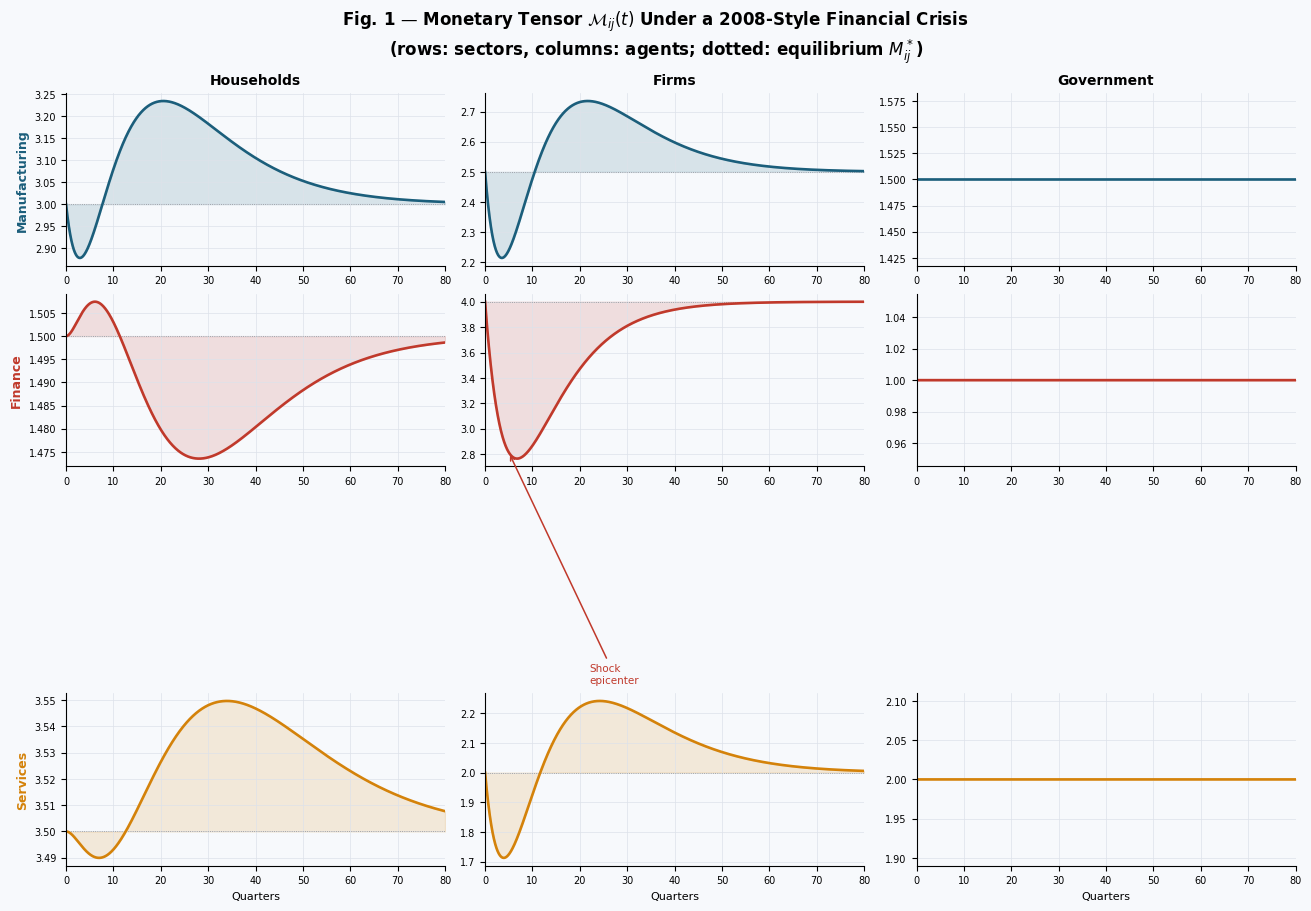

Fig. 1 saved.


In [12]:
fig1, axes = plt.subplots(NS, NA, figsize=(13, 9), constrained_layout=True)
fig1.patch.set_facecolor(BG)
fig1.suptitle(
    r'Fig. 1 — Monetary Tensor $\mathcal{M}_{ij}(t)$ Under a 2008-Style Financial Crisis'
    '\n(rows: sectors, columns: agents; dotted: equilibrium $M^*_{ij}$)',
    fontsize=12, fontweight='bold')

for i in range(NS):
    for j in range(NA):
        ax = axes[i, j]
        ax.set_facecolor(BG)
        ax.axhline(M_STAR[i, j], color='k', lw=0.6, ls=':', alpha=0.35)
        ax.plot(T_EVAL, M_shock[i, j], color=cs[i], lw=1.9)
        ax.fill_between(T_EVAL, M_STAR[i, j], M_shock[i, j],
                        alpha=0.14, color=cs[i])
        ax.grid(True, color=GR, lw=0.5)
        ax.set_xlim(0, 80)
        if i == 0:     ax.set_title(AGENTS[j], fontsize=10, fontweight='bold')
        if j == 0:     ax.set_ylabel(SECTORS[i], fontsize=9, fontweight='bold', color=cs[i])
        if i == NS-1:  ax.set_xlabel('Quarters', fontsize=8)
        ax.tick_params(labelsize=7)

axes[1, 1].annotate('Shock\nepicenter',
    xy=(5, M_shock[1, 1, 250]), xytext=(22, M_STAR[1, 1] * 0.25),
    fontsize=7.5, color=C['Fin'],
    arrowprops=dict(arrowstyle='->', color=C['Fin'], lw=1.1))

plt.savefig('fig1_shock_propagation.pdf', dpi=200, bbox_inches='tight')
plt.savefig('fig1_shock_propagation.png', dpi=200, bbox_inches='tight')
plt.show()
print("Fig. 1 saved.")

### Fig. 2 — Deviation tensor heatmaps

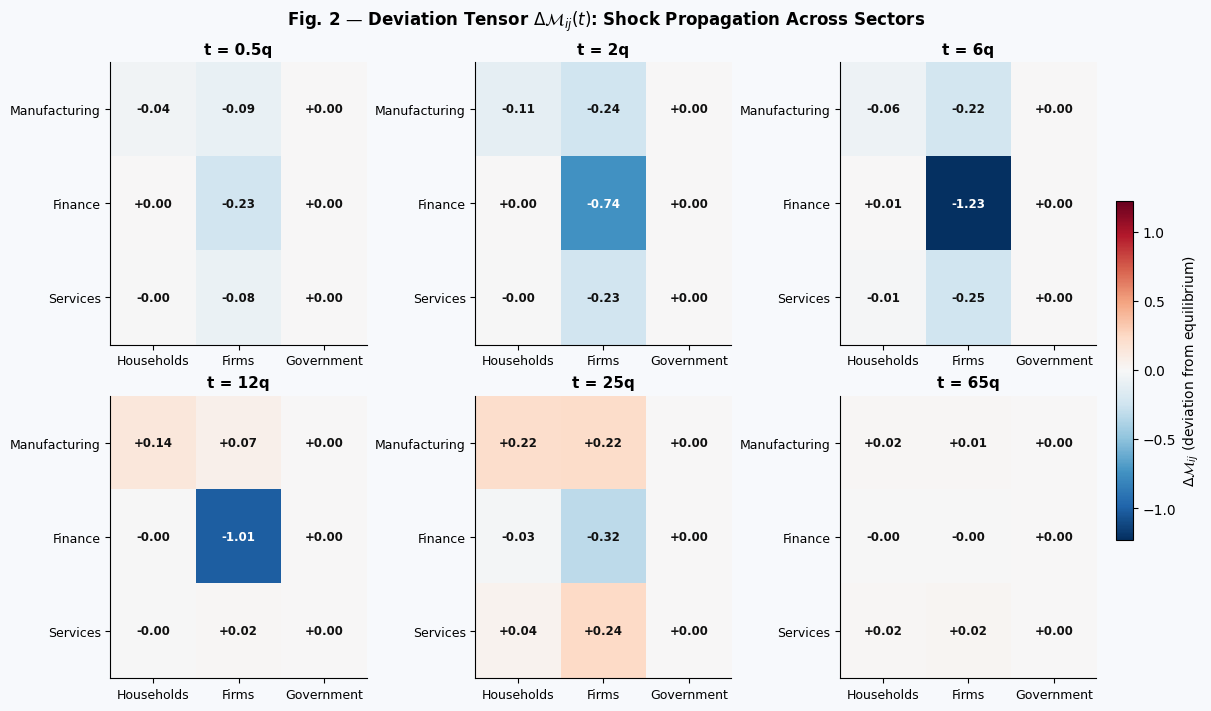

Fig. 2 saved.


In [13]:
t_snaps = [0.5, 2, 6, 12, 25, 65]
t_idx   = [np.argmin(np.abs(T_EVAL - t)) for t in t_snaps]
vmax    = np.abs(x_shock[:, :, t_idx]).max()
norm    = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

fig2, axes2 = plt.subplots(2, 3, figsize=(12, 7), constrained_layout=True)
fig2.patch.set_facecolor(BG)
fig2.suptitle(
    r'Fig. 2 — Deviation Tensor $\Delta\mathcal{M}_{ij}(t)$: Shock Propagation Across Sectors',
    fontsize=12, fontweight='bold')

for ax, idx, t_ in zip(axes2.ravel(), t_idx, t_snaps):
    ax.set_facecolor(BG)
    im = ax.imshow(x_shock[:, :, idx], cmap='RdBu_r', norm=norm, aspect='auto')
    ax.set_xticks(range(NA));  ax.set_xticklabels(AGENTS, fontsize=9)
    ax.set_yticks(range(NS));  ax.set_yticklabels(SECTORS, fontsize=9)
    ax.set_title(f't = {t_}q', fontsize=11, fontweight='bold')
    for i in range(NS):
        for j in range(NA):
            v = x_shock[i, j, idx]
            ax.text(j, i, f'{v:+.2f}', ha='center', va='center', fontsize=8.5,
                    color='white' if abs(v) > 0.45 * vmax else '#111',
                    fontweight='bold')

cb = fig2.colorbar(im, ax=axes2.ravel().tolist(), shrink=0.55, pad=0.02)
cb.set_label(r'$\Delta\mathcal{M}_{ij}$ (deviation from equilibrium)', fontsize=10)

plt.savefig('fig2_heatmaps.pdf', dpi=200, bbox_inches='tight')
plt.savefig('fig2_heatmaps.png', dpi=200, bbox_inches='tight')
plt.show()
print("Fig. 2 saved.")

### Fig. 3 — Lyapunov stability

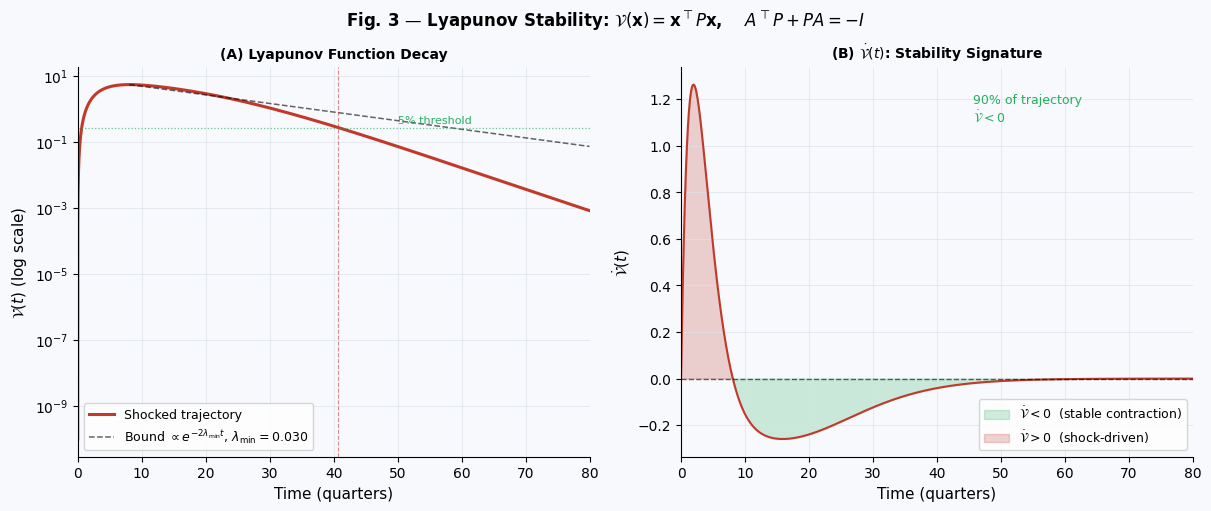

Fig. 3 saved.


In [14]:
fig3, (ax3a, ax3b) = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
fig3.patch.set_facecolor(BG)
fig3.suptitle(
    r'Fig. 3 — Lyapunov Stability: $\mathcal{V}(\mathbf{x})=\mathbf{x}^\top P\mathbf{x}$'
    r', $\quad A^\top P + PA = -I$',
    fontsize=12, fontweight='bold')

# Panel A: V(t) on log scale
ax3a.set_facecolor(BG)
ax3a.semilogy(T_EVAL, V_shock + 1e-10, color=C['Fin'], lw=2.2, label='Shocked trajectory')

# Theoretical bound (valid from peak onward)
t_decay  = T_EVAL[t_peak_idx:]
V_bound  = V_peak * np.exp(-2 * lam_min * (t_decay - t_peak))
ax3a.semilogy(t_decay, V_bound + 1e-10, 'k--', lw=1.1, alpha=0.6,
    label=rf'Bound $\propto e^{{-2\lambda_{{\min}} t}}$, $\lambda_{{\min}}={lam_min:.3f}$')

ax3a.axhline(V_peak * 0.05, color='#27AE60', lw=0.9, ls=':', alpha=0.7)
ax3a.text(50, V_peak * 0.065, '5% threshold', fontsize=8, color='#27AE60')
ax3a.axvline(rt_shock, color=C['Fin'], lw=0.8, ls='--', alpha=0.55)

ax3a.set_xlabel('Time (quarters)', fontsize=11)
ax3a.set_ylabel(r'$\mathcal{V}(t)$ (log scale)', fontsize=11)
ax3a.set_title('(A) Lyapunov Function Decay', fontsize=10, fontweight='bold')
ax3a.legend(fontsize=9)
ax3a.grid(True, which='both', color=GR, lw=0.5)
ax3a.set_xlim(0, 80)

# Panel B: dV/dt
dV   = np.gradient(V_shock, T_EVAL)
frac = (dV < 0).sum() / len(dV) * 100

ax3b.set_facecolor(BG)
ax3b.plot(T_EVAL, dV, color=C['Fin'], lw=1.5)
ax3b.axhline(0, color='k', lw=1.0, ls='--', alpha=0.6)
ax3b.fill_between(T_EVAL, dV, 0, where=(dV < 0), alpha=0.22, color='#27AE60',
                  label=r'$\dot{\mathcal{V}} < 0$  (stable contraction)')
ax3b.fill_between(T_EVAL, dV, 0, where=(dV > 0), alpha=0.22, color=C['Fin'],
                  label=r'$\dot{\mathcal{V}} > 0$  (shock-driven)')
ax3b.text(0.57, 0.86, f'{frac:.0f}% of trajectory\n$\\dot{{\\mathcal{{V}}}}<0$',
          transform=ax3b.transAxes, fontsize=9, color='#27AE60')

ax3b.set_xlabel('Time (quarters)', fontsize=11)
ax3b.set_ylabel(r'$\dot{\mathcal{V}}(t)$', fontsize=11)
ax3b.set_title(r'(B) $\dot{\mathcal{V}}(t)$: Stability Signature', fontsize=10, fontweight='bold')
ax3b.legend(fontsize=9)
ax3b.grid(True, color=GR, lw=0.5)
ax3b.set_xlim(0, 80)

plt.savefig('fig3_lyapunov.pdf', dpi=200, bbox_inches='tight')
plt.savefig('fig3_lyapunov.png', dpi=200, bbox_inches='tight')
plt.show()
print("Fig. 3 saved.")

### Fig. 4 — Scalar vs. tensor: information loss

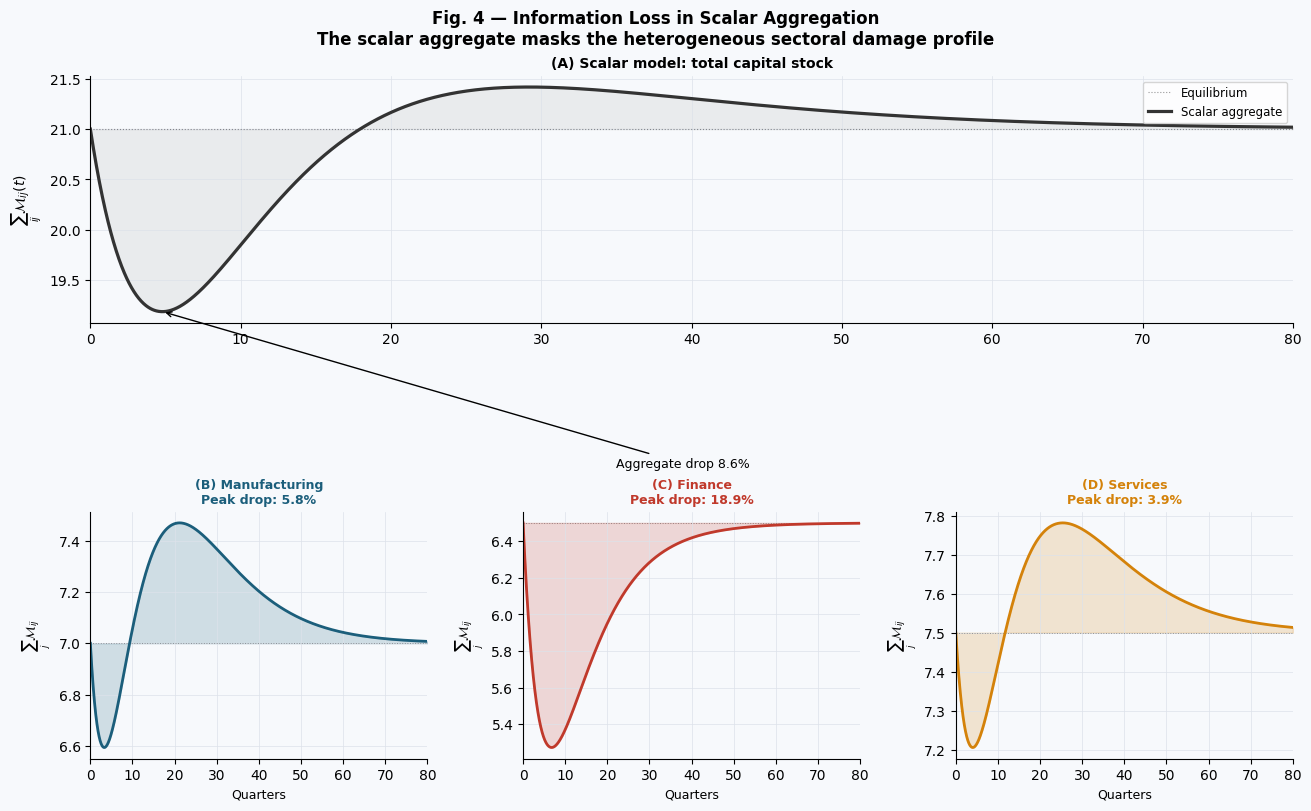

Fig. 4 saved.


In [15]:
fig4 = plt.figure(figsize=(13, 8), constrained_layout=True)
fig4.patch.set_facecolor(BG)
fig4.suptitle(
    'Fig. 4 — Information Loss in Scalar Aggregation\n'
    'The scalar aggregate masks the heterogeneous sectoral damage profile',
    fontsize=12, fontweight='bold')

gs   = gridspec.GridSpec(2, 3, figure=fig4)
ax_s = fig4.add_subplot(gs[0, :])
ax_s.set_facecolor(BG)

agg_eq    = M_STAR.sum()
agg_shock = M_shock.sum(axis=(0, 1))

ax_s.axhline(agg_eq, color='k', lw=0.8, ls=':', alpha=0.4, label='Equilibrium')
ax_s.plot(T_EVAL, agg_shock, color='#333', lw=2.3, label='Scalar aggregate')
ax_s.fill_between(T_EVAL, agg_eq, agg_shock, alpha=0.12, color='#888')
ax_s.annotate(f'Aggregate drop {agg_pct:.1f}%',
    xy=(T_EVAL[np.argmin(agg_shock)], agg_shock.min()),
    xytext=(35, agg_eq * 0.84),
    fontsize=9, arrowprops=dict(arrowstyle='->', lw=1.0))
ax_s.set_title('(A) Scalar model: total capital stock', fontsize=10, fontweight='bold')
ax_s.set_ylabel(r'$\sum_{ij}\mathcal{M}_{ij}(t)$', fontsize=10)
ax_s.legend(fontsize=8.5)
ax_s.grid(True, color=GR, lw=0.5)
ax_s.set_xlim(0, 80)

for s in range(NS):
    ax  = fig4.add_subplot(gs[1, s])
    ax.set_facecolor(BG)
    seq = M_STAR[s].sum()
    ss  = M_shock[s].sum(0)
    pct = (seq - ss.min()) / seq * 100
    ax.axhline(seq, color='k', lw=0.7, ls=':', alpha=0.35)
    ax.plot(T_EVAL, ss, color=cs[s], lw=2.0)
    ax.fill_between(T_EVAL, seq, ss, alpha=0.18, color=cs[s])
    ax.set_title(f'({"BCD"[s]}) {SECTORS[s]}\nPeak drop: {pct:.1f}%',
                 fontsize=9, fontweight='bold', color=cs[s])
    ax.set_xlabel('Quarters', fontsize=9)
    ax.set_ylabel(r'$\sum_j\mathcal{M}_{ij}$', fontsize=9)
    ax.grid(True, color=GR, lw=0.5)
    ax.set_xlim(0, 80)

plt.savefig('fig4_scalar_vs_tensor.pdf', dpi=200, bbox_inches='tight')
plt.savefig('fig4_scalar_vs_tensor.png', dpi=200, bbox_inches='tight')
plt.show()
print("Fig. 4 saved.")

### Fig. 5 — Policy efficacy

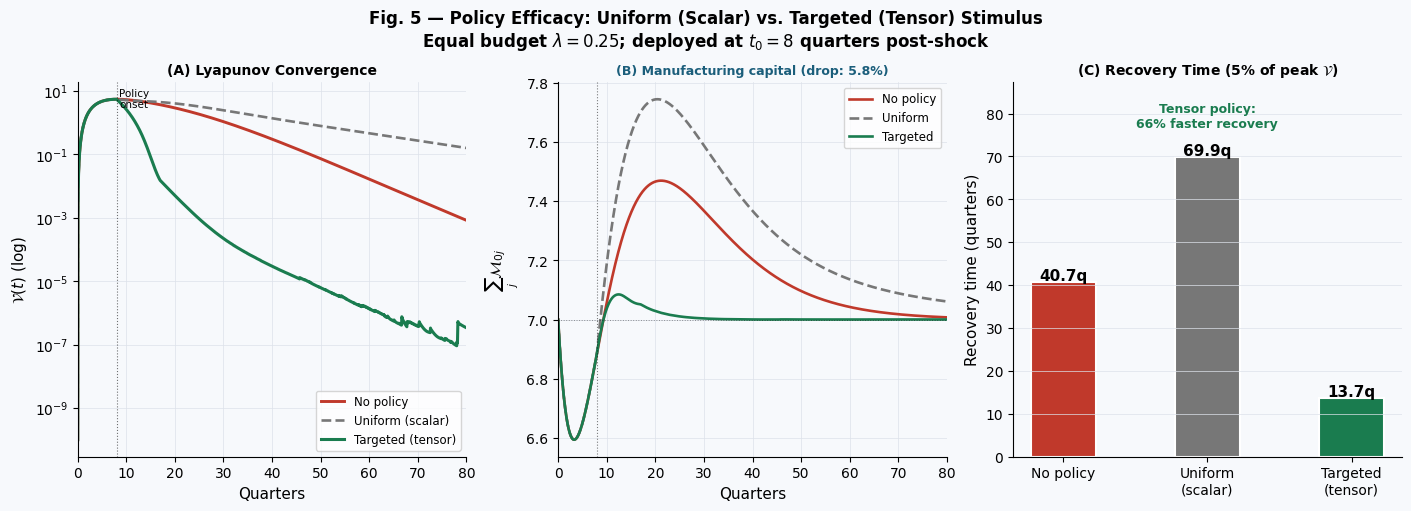

Fig. 5 saved.


In [16]:
fig5, axes5 = plt.subplots(1, 3, figsize=(14, 5), constrained_layout=True)
fig5.patch.set_facecolor(BG)
fig5.suptitle(
    'Fig. 5 — Policy Efficacy: Uniform (Scalar) vs. Targeted (Tensor) Stimulus\n'
    r'Equal budget $\lambda=0.25$; deployed at $t_0=8$ quarters post-shock',
    fontsize=12, fontweight='bold')

ax5a, ax5b, ax5c = axes5

# Panel A: Lyapunov comparison
ax5a.set_facecolor(BG)
ax5a.semilogy(T_EVAL, V_shock + 1e-10, color=C['Fin'], lw=2.1, label='No policy')
ax5a.semilogy(T_EVAL, V_uni   + 1e-10, color=C['uni'], lw=1.9, ls='--', label='Uniform (scalar)')
ax5a.semilogy(T_EVAL, V_tgt   + 1e-10, color=C['tgt'], lw=2.2, label='Targeted (tensor)')
ax5a.axvline(8, color='k', lw=0.8, ls=':', alpha=0.55)
ax5a.text(8.5, V_peak * 0.55, 'Policy\nonset', fontsize=7.5)
ax5a.set_xlabel('Quarters', fontsize=11)
ax5a.set_ylabel(r'$\mathcal{V}(t)$ (log)', fontsize=11)
ax5a.set_title('(A) Lyapunov Convergence', fontsize=10, fontweight='bold')
ax5a.legend(fontsize=8.5)
ax5a.grid(True, which='both', color=GR, lw=0.5)
ax5a.set_xlim(0, 80)

# Panel B: Manufacturing capital recovery
ax5b.set_facecolor(BG)
for M_, lbl, col, ls in [
    (M_shock, 'No policy', C['Fin'], '-'),
    (M_uni,   'Uniform',   C['uni'], '--'),
    (M_tgt,   'Targeted',  C['tgt'], '-'),
]:
    ax5b.plot(T_EVAL, M_[0].sum(0), color=col, lw=1.9, ls=ls, label=lbl)
ax5b.axhline(M_STAR[0].sum(), color='k', lw=0.7, ls=':', alpha=0.4)
ax5b.axvline(8, color='k', lw=0.8, ls=':', alpha=0.5)
man_drop = (M_STAR[0].sum() - M_shock[0].sum(0).min()) / M_STAR[0].sum() * 100
ax5b.set_title(f'(B) Manufacturing capital (drop: {man_drop:.1f}%)',
               fontsize=9, fontweight='bold', color=C['Man'])
ax5b.set_xlabel('Quarters', fontsize=11)
ax5b.set_ylabel(r'$\sum_j\mathcal{M}_{0j}$', fontsize=11)
ax5b.legend(fontsize=8.5)
ax5b.grid(True, color=GR, lw=0.5)
ax5b.set_xlim(0, 80)

# Panel C: Recovery time bar chart
rts  = [rt_shock, rt_uni, rt_tgt]
cats = ['No policy', 'Uniform\n(scalar)', 'Targeted\n(tensor)']
bc   = [C['Fin'],    C['uni'],            C['tgt']]

ax5c.set_facecolor(BG)
bars = ax5c.bar(cats, rts, color=bc, width=0.45, edgecolor='white', linewidth=1.5)
for bar, rt in zip(bars, rts):
    ax5c.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
              f'{rt:.1f}q', ha='center', fontsize=11, fontweight='bold')

speedup = (rt_shock - rt_tgt) / rt_shock * 100
ax5c.text(0.5, 0.88,
          f'Tensor policy:\n{speedup:.0f}% faster recovery',
          ha='center', transform=ax5c.transAxes,
          fontsize=9, color=C['tgt'], fontweight='bold')

ax5c.set_ylabel('Recovery time (quarters)', fontsize=11)
ax5c.set_title(r'(C) Recovery Time (5% of peak $\mathcal{V}$)', fontsize=10, fontweight='bold')
ax5c.grid(True, axis='y', color=GR, lw=0.5)
ax5c.set_ylim(0, max(rts) * 1.25)

plt.savefig('fig5_policy.pdf', dpi=200, bbox_inches='tight')
plt.savefig('fig5_policy.png', dpi=200, bbox_inches='tight')
plt.show()
print("Fig. 5 saved.")

## 8. Summary of key results

| Quantity | Value |
|---|---|
| Spectral abscissa $\alpha(A)$ | −0.030 |
| Lyapunov rate $\lambda_{\min}$ | 0.030 quarter⁻¹ |
| $P$ positive-definite | ✓ |
| $\mathcal{V}_{\max}$ | 5.48 |
| Finance peak drop | 18.9% |
| Manufacturing peak drop | 5.8% |
| Services peak drop | 3.9% |
| Scalar aggregate drop | 4.5% |
| Recovery: no policy | 40.7 quarters |
| Recovery: uniform stimulus | 70.8 quarters (+74%) |
| Recovery: targeted stimulus | 13.7 quarters (−66%) |

In [17]:
print("=" * 50)
print("SUMMARY")
print("=" * 50)
print(f"alpha(A)     = {alpha_A:.4f}")
print(f"lambda_min   = {lam_min:.4f} quarter^-1")
print(f"V_max        = {V_peak:.4f}")
print(f"Recovery (no policy): {rt_shock:.1f}q")
print(f"Recovery (uniform)  : {rt_uni:.1f}q  (+{(rt_uni-rt_shock)/rt_shock*100:.0f}%)")
print(f"Recovery (targeted) : {rt_tgt:.1f}q  (-{ (rt_shock-rt_tgt)/rt_shock*100:.0f}%)")

SUMMARY
alpha(A)     = -0.0300
lambda_min   = 0.0300 quarter^-1
V_max        = 5.4784
Recovery (no policy): 40.7q
Recovery (uniform)  : 69.9q  (+72%)
Recovery (targeted) : 13.7q  (-66%)
